In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout, BatchNormalization, LeakyReLU, Reshape
from keras.layers import Conv2D, Conv2DTranspose
from keras.datasets import fashion_mnist
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

Loaded Successfully: (60000, 28, 28, 1)


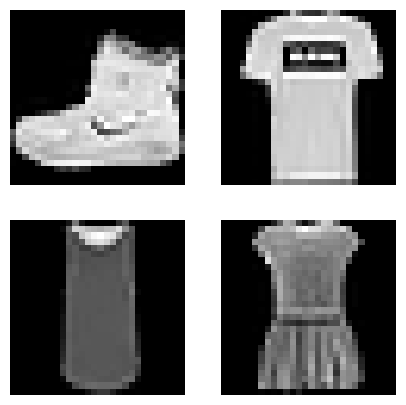

In [2]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context
from keras.datasets import fashion_mnist
(train_x, _), (_, _) = fashion_mnist.load_data()
train_x = train_x / 255.0
train_x = train_x.reshape(-1, 28, 28, 1)
print("Loaded Successfully:", train_x.shape)

# Show sample images
plt.figure(figsize=(5,5))
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.imshow(train_x[i].reshape(28,28), cmap='gray')
    plt.axis('off')
plt.show()


In [3]:
# Normalize [-1,1]
train_x = train_x * 2 - 1

In [4]:
generator = Sequential()
generator.add(Dense(256, input_dim=100))
generator.add(LeakyReLU(0.2))
generator.add(BatchNormalization())
generator.add(Dense(512))
generator.add(LeakyReLU(0.2))
generator.add(BatchNormalization())
generator.add(Dense(1024))
generator.add(LeakyReLU(0.2))
generator.add(BatchNormalization())
generator.add(Dense(28*28*1, activation='tanh'))
generator.add(Reshape((28,28,1)))
generator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │       803,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,493,520 (5.70 MB)

 Trainable params: 1,489,936 (5.68 MB)

 Non-trainable params: 3,584 (14.00 KB)

In [5]:
discriminator = Sequential()
discriminator.add(Flatten(input_shape=(28,28,1)))
discriminator.add(Dense(512))
discriminator.add(LeakyReLU(0.2))
discriminator.add(Dropout(0.5))
discriminator.add(Dense(256))
discriminator.add(LeakyReLU(0.2))
discriminator.add(Dropout(0.5))
discriminator.add(Dense(1, activation='sigmoid'))
discriminator.compile(optimizer='adam', loss='binary_crossentropy')
discriminator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 533,505 (2.04 MB)

 Trainable params: 533,505 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
discriminator.trainable = False
GAN = Sequential([generator, discriminator])
GAN.compile(optimizer='adam', loss='binary_crossentropy')
GAN.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 28, 28, 1)      │     1,493,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 1)              │       533,505 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,027,025 (7.73 MB)

 Trainable params: 1,489,936 (5.68 MB)

 Non-trainable params: 537,089 (2.05 MB)


Epoch 1/15
Step 0/100
Step 50/100


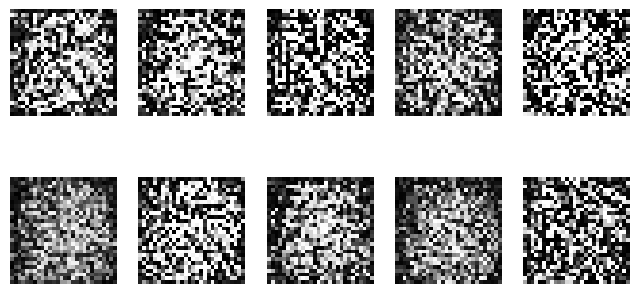


Epoch 2/15
Step 0/100
Step 50/100

Epoch 3/15
Step 0/100
Step 50/100

Epoch 4/15
Step 0/100
Step 50/100

Epoch 5/15
Step 0/100
Step 50/100

Epoch 6/15
Step 0/100
Step 50/100

Epoch 7/15
Step 0/100
Step 50/100

Epoch 8/15
Step 0/100
Step 50/100

Epoch 9/15
Step 0/100
Step 50/100

Epoch 10/15
Step 0/100
Step 50/100

Epoch 11/15
Step 0/100
Step 50/100


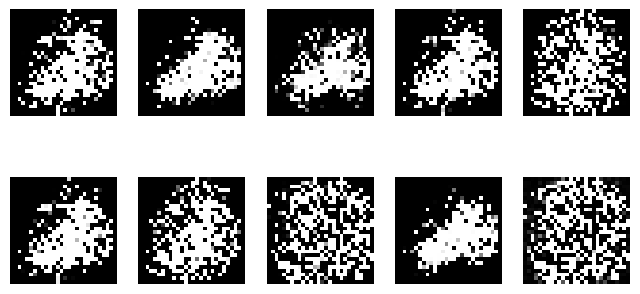


Epoch 12/15
Step 0/100
Step 50/100

Epoch 13/15
Step 0/100
Step 50/100

Epoch 14/15
Step 0/100
Step 50/100

Epoch 15/15
Step 0/100
Step 50/100


In [7]:
epochs = 40
batch_size = 100
noise_dim = 100

steps_per_epoch = 100  # reduce for faster testing
for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")
    for i in range(steps_per_epoch):
        if i % 50 == 0:
            print(f"Step {i}/{steps_per_epoch}")
        # Noise
        noise = np.random.normal(0, 1, (batch_size, noise_dim))
        # Fake images
        fake_images = generator(noise, training=False)
        # Real images
        real_images = train_x[i*batch_size:(i+1)*batch_size]
        # Labels
        real_labels = np.ones((batch_size,1))
        fake_labels = np.zeros((batch_size,1))
        # Train Discriminator
        discriminator.trainable = True
        d_loss_real = discriminator.train_on_batch(real_images,
real_labels)
        d_loss_fake = discriminator.train_on_batch(fake_images,
fake_labels)
        # Train Generator
        noise = np.random.normal(0,1,(batch_size, noise_dim))
        misleading_labels = np.ones((batch_size,1))
        discriminator.trainable = False
        g_loss = GAN.train_on_batch(noise, misleading_labels)
    # Show images
    if epoch % 8 == 0:
        noise = np.random.normal(0,1,(10, noise_dim))
        gen_images = generator(noise, training=False)
        plt.figure(figsize=(8,4))
        for k in range(10):
            plt.subplot(2,5,k+1)
            plt.imshow(gen_images[k].numpy().reshape(28,28),
cmap='gray')
            plt.axis('off')
        plt.show()

Training Complete!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step


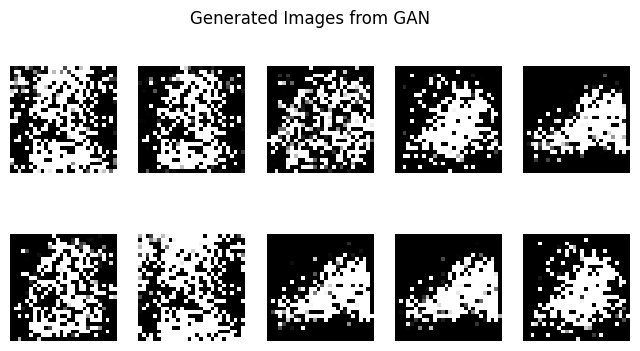

In [8]:
print("Training Complete!")
noise = np.random.normal(0,1,(10, noise_dim))
generated_images = generator.predict(noise)
plt.figure(figsize=(8,4))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(generated_images[i].reshape(28,28), cmap='gray')
    plt.axis('off')
plt.suptitle("Generated Images from GAN")
plt.show()